# jjh

---

**Project**
- CCRM

**Module**
- notebooks

**Author**
- Hyeok

**Created**
- 2026-03-07

**Purpose**
- TODO: EasyEnsemble
---


In [30]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [32]:
# 1. 데이터 로드
# 각자의 파일 경로에 맞춰 수정하기
df_encoded = pd.read_csv('./data/df_encoded_final.csv')

In [33]:
# 2. 데이터 전처리 (에러 방지용 매핑 및 X/y 분리)
mapping = {'0-20': 0, '20-40': 1, '40-60': 2, '60-80': 3, '80-100': 4, '100+': 5}
if 'trans_ct_bin' in df_encoded.columns and df_encoded['trans_ct_bin'].dtype == 'object':
    df_encoded['trans_ct_bin'] = df_encoded['trans_ct_bin'].map(mapping).fillna(-1).astype(int)
    print("✅ trans_ct_bin 매핑 완료")

# 타겟 변수 설정 (이탈 여부 컬럼명 확인 필요)
target_col = 'churn' 
y = df_encoded[target_col]
X = df_encoded.drop(columns=[target_col])

# 혹시 남아있을 수 있는 ID성 컬럼 제거 (학습 방해 요소)
if 'CLIENTNUM' in X.columns:
    X = X.drop(columns=['CLIENTNUM'])

✅ trans_ct_bin 매핑 완료


In [34]:
# 3. 데이터 분할 (불균형 데이터이므로 stratify 필수)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
# 4. 이지 앙상블 모델 정의 및 학습
# n_jobs=-1로 M2 맥북의 멀티코어를 활용합니다.
ee_model = EasyEnsembleClassifier(
    n_estimators=10, 
    random_state=42, 
    n_jobs=-1
)
print("⏳ 이지 앙상블 학습 시작...")
ee_model.fit(X_train, y_train)
print("✅ 학습 완료!")

⏳ 이지 앙상블 학습 시작...
✅ 학습 완료!


In [38]:
# 5. 성능 평가
y_pred = ee_model.predict(X_test)
print("\n" + "="*50)
print(f"🏆 EasyEnsemble Accuracy: {accuracy_score(y_test, y_pred):.6f}")
print("="*50)
print(classification_report(y_test, y_pred))


🏆 EasyEnsemble Accuracy: 0.920533
              precision    recall  f1-score   support

           0       0.68      0.94      0.79       325
           1       0.99      0.92      0.95      1701

    accuracy                           0.92      2026
   macro avg       0.84      0.93      0.87      2026
weighted avg       0.94      0.92      0.93      2026



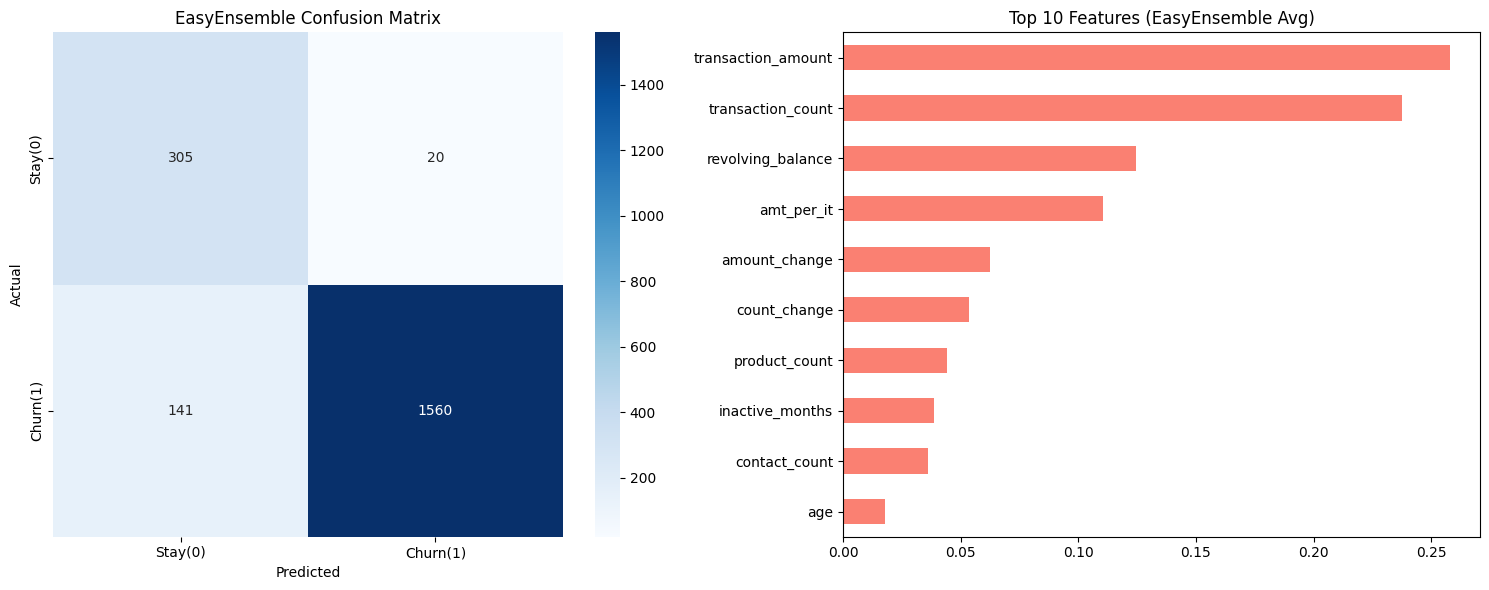

In [ ]:
# 6. 시각화 (Confusion Matrix & Feature Importance)
plt.figure(figsize=(15, 6))

# 좌측: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stay(0)', 'Churn(1)'], 
            yticklabels=['Stay(0)', 'Churn(1)'])
plt.title('EasyEnsemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 우측: Feature Importance (앙상블 내 모델들의 평균 중요도)
# AdaBoost 기반이므로 개별 estimator의 feature_importances_를 평균 냅니다.
importances = np.mean([est.steps[1][1].feature_importances_ for est in ee_model.estimators_], axis=0)
feat_importances = pd.Series(importances, index=X.columns).nlargest(10)

plt.subplot(1, 2, 2)
feat_importances.plot(kind='barh', color='salmon')
plt.title('Top 10 Features (EasyEnsemble Avg)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()